In [146]:
import opendatasets as od
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

In [147]:
od.download("https://www.kaggle.com/datasets/uciml/mushroom-classification")

Skipping, found downloaded files in "./mushroom-classification" (use force=True to force download)


In [148]:
df = pd.read_csv("/content/mushroom-classification/mushrooms.csv")
df_original = df.copy()
df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


**Общая статистика**

In [149]:
df = df.replace('?', np.nan)

In [150]:
df.shape

(8124, 23)

In [151]:
df.columns

Index(['class', 'cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor',
       'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color',
       'stalk-shape', 'stalk-root', 'stalk-surface-above-ring',
       'stalk-surface-below-ring', 'stalk-color-above-ring',
       'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-number',
       'ring-type', 'spore-print-color', 'population', 'habitat'],
      dtype='object')

In [152]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                5644 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  stalk-color-above-ring  

In [153]:
df.describe()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
count,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,...,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124
unique,2,6,4,10,2,9,2,2,2,12,...,4,9,9,1,4,3,5,9,6,7
top,e,x,y,n,f,n,f,c,b,b,...,s,w,w,p,w,o,p,w,v,d
freq,4208,3656,3244,2284,4748,3528,7914,6812,5612,1728,...,4936,4464,4384,8124,7924,7488,3968,2388,4040,3148


**Пропуски**

In [154]:
df.isna().sum()

,0
class,0
cap-shape,0
cap-surface,0
cap-color,0
bruises,0
odor,0
gill-attachment,0
gill-spacing,0
gill-size,0
gill-color,0


In [155]:
(df.isna().mean() * 100).round(2)

,0
class,0.00
cap-shape,0.00
cap-surface,0.00
cap-color,0.00
bruises,0.00
odor,0.00
gill-attachment,0.00
gill-spacing,0.00
gill-size,0.00
gill-color,0.00


**ДУБЛИКАТЫ**

In [156]:
df.duplicated().sum()

np.int64(0)

**УНИКАЛЬНЫЕ ЗНАЧЕНИЯ И КОНСТАНТЫ**

In [157]:
df.nunique()

,0
class,2
cap-shape,6
cap-surface,4
cap-color,10
bruises,2
odor,9
gill-attachment,2
gill-spacing,2
gill-size,2
gill-color,12


In [158]:
unique_counts = df.nunique()
unique_counts[unique_counts <= 1]

,0
veil-type,1


**БАЛАНС КЛАССОВ**

In [159]:
df["class"].value_counts(dropna=False)

,count
class,
e,4208
p,3916


In [160]:
(df["class"].value_counts(normalize=True) * 100).round(2)

,proportion
class,
e,51.8
p,48.2


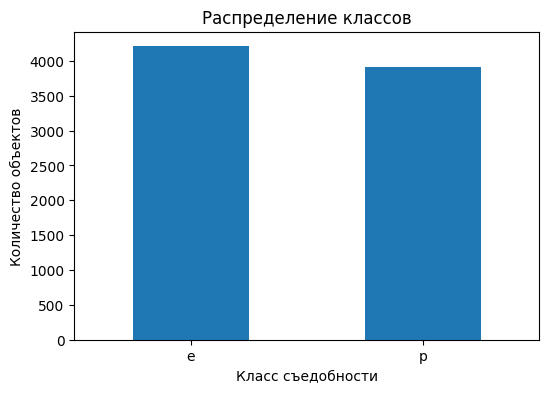

In [161]:
df["class"].value_counts().plot(kind="bar", figsize=(6, 4))
plt.title("Распределение классов")
plt.xlabel("Класс съедобности")
plt.ylabel("Количество объектов")
plt.xticks(rotation=0)
plt.show()

**РАСПРЕДЕЛЕНИЯ ПРИЗНАКОВ**

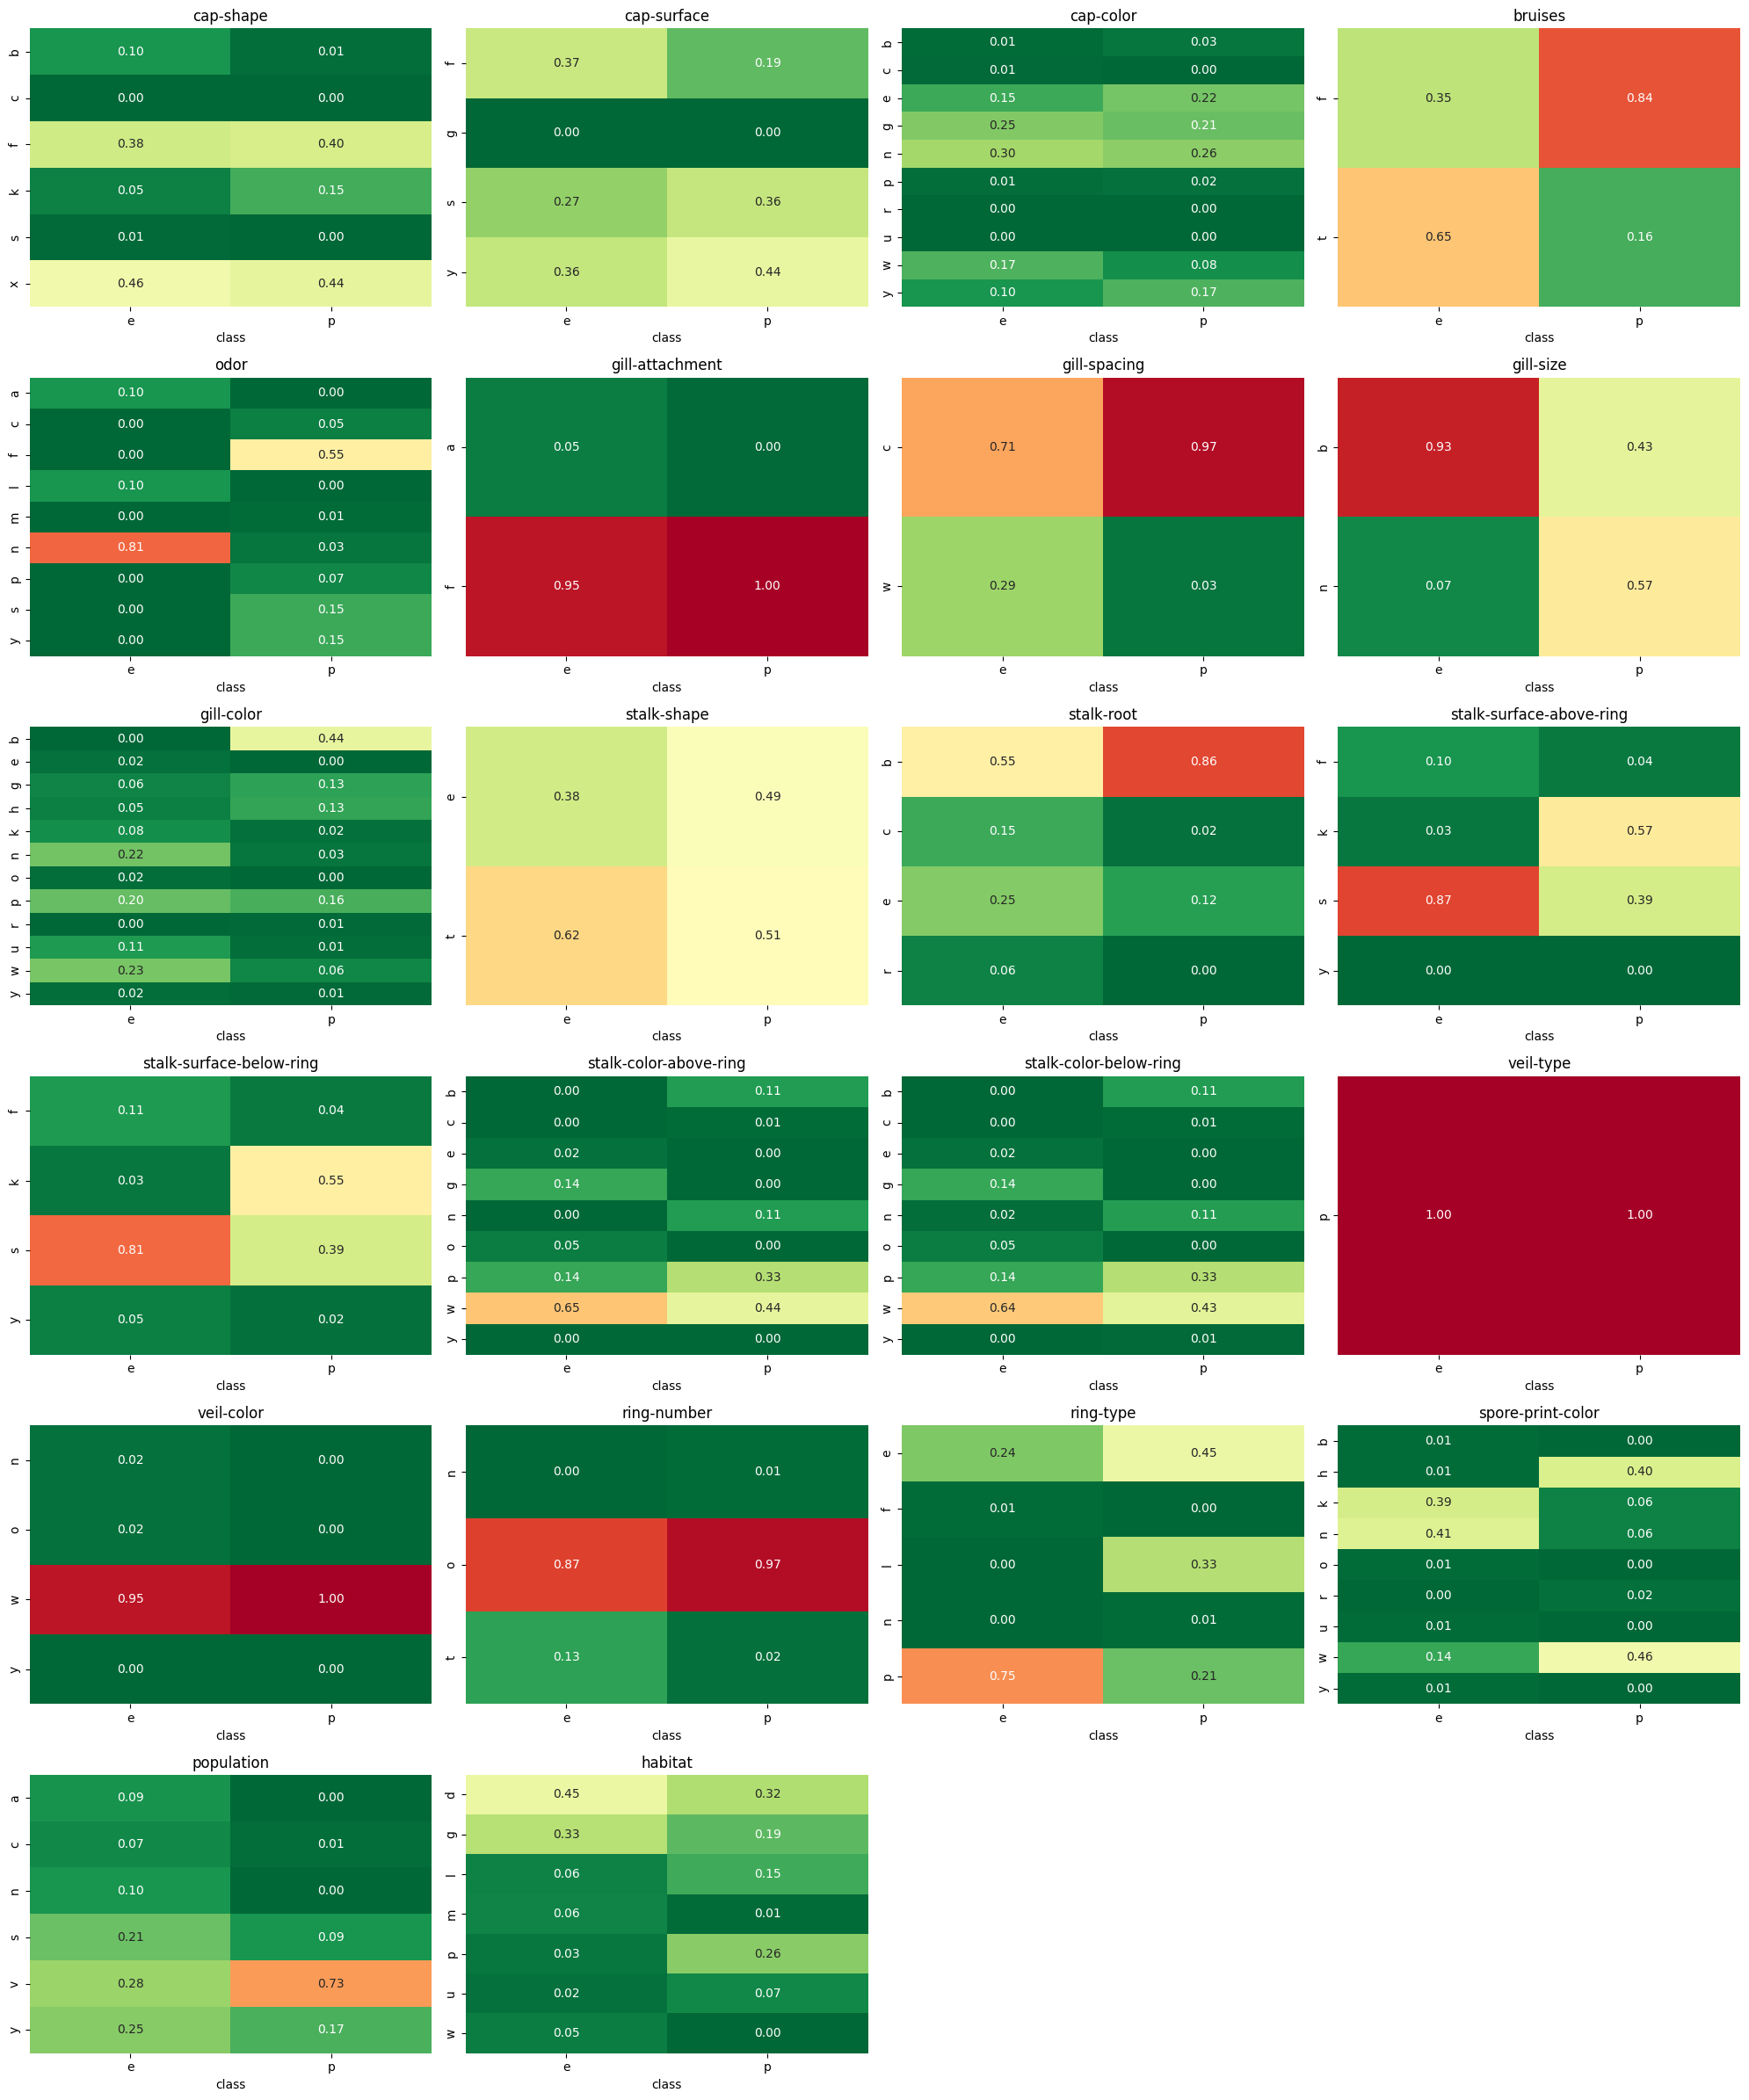

In [140]:
cat_features = [c for c in df.columns if c != 'class']

n_cols = 4
n_rows = int(np.ceil(len(cat_features) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axes = axes.flatten()

for ax, col in zip(axes, cat_features):
    ct = pd.crosstab(df[col], df['class'], normalize='columns')
    sns.heatmap(ct, annot=True, fmt='.2f', cmap='RdYlGn_r',
                cbar=False, ax=ax, vmin=0, vmax=1)
    ax.set_title(col)
    ax.set_xlabel('class')
    ax.set_ylabel('')

for j in range(len(cat_features), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

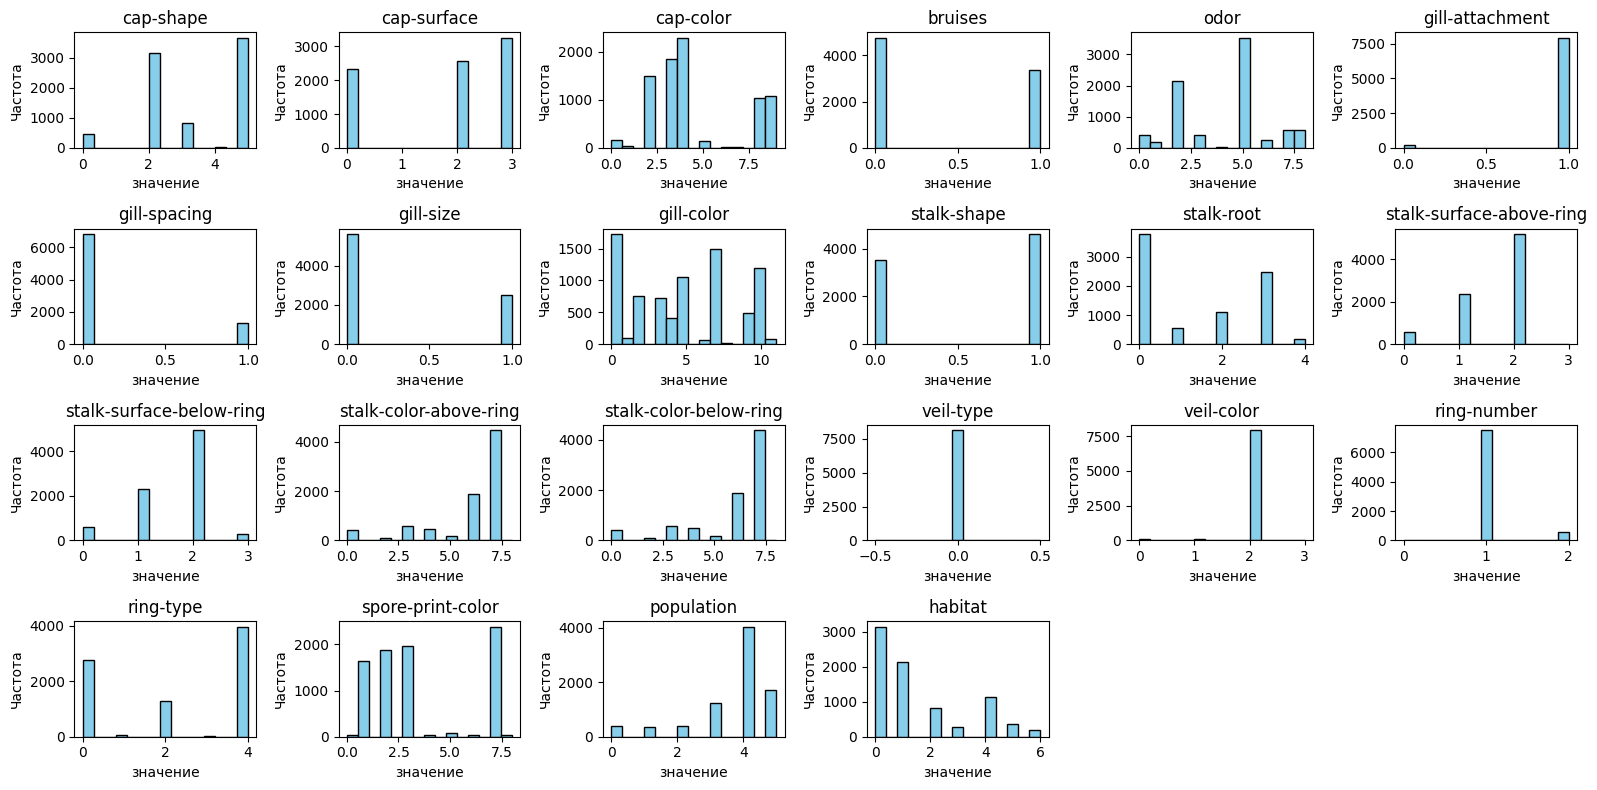

In [141]:
df_encoded = df.copy()
le = LabelEncoder()
for col in df_encoded.columns:
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

fig, axes = plt.subplots(4, 6, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(cat_features):
    if col in df_encoded.columns:
        axes[i].hist(df_encoded[col], bins=15, color='skyblue', edgecolor='black')
        axes[i].set_title(col)
        axes[i].set_xlabel('значение')
        axes[i].set_ylabel('Частота')
for j in range(len(cat_features), len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()

**ПРИОРИТЕТНЫЕ ПРИЗНАКИ**

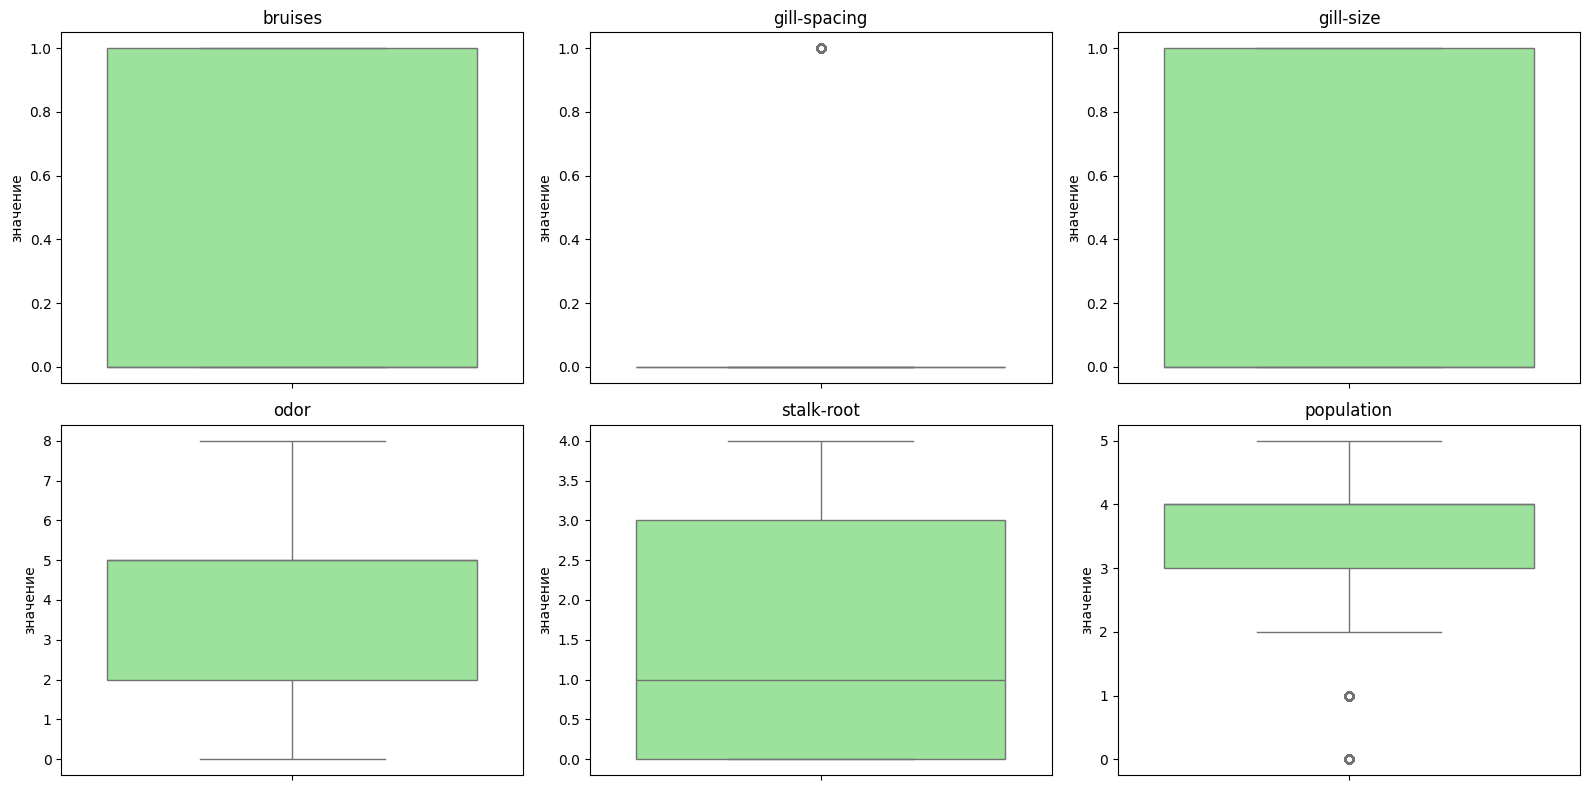

In [142]:
priority_features = ['bruises', 'gill-spacing', 'gill-size', 'odor', 'stalk-root', 'population']
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for ax, col in zip(axes, priority_features):
    if col in df_encoded.columns:
        sns.boxplot(y=df_encoded[col], ax=ax, color='lightgreen')
        ax.set_title(col)
        ax.set_ylabel('значение')

        Q1 = df_encoded[col].quantile(0.25)
        Q3 = df_encoded[col].quantile(0.75)
        IQR = Q3 - Q1
        lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
        outliers = df_encoded[(df_encoded[col] < lower) | (df_encoded[col] > upper)]
for j in range(len(priority_features), len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()

**ПРОФИЛЬ ТАБЛИЦЫ**

In [143]:
print("Количество строк:", len(df))
print("Количество столбцов:", len(df.columns))
print("Пропущенных ячеек:", df.isna().sum().sum())
print("Полных копий:", df.duplicated().sum())

n_rows, n_cols = df_original.shape

missing_mask = df_original.isna() | (df_original == '?')
missing_counts = missing_mask.sum()
missing_counts = missing_counts[missing_counts > 0]

def count_format_errors(series):
    s = series.astype(str)
    return (~s.str.fullmatch(r'[A-Za-z?]')).sum()
format_error_total = df_original.apply(count_format_errors).sum()

const_cols = [c for c in df_original.columns
              if df_original[c].nunique(dropna=False) <= 1]

class_missing = int(missing_mask['class'].sum())

rare_cols = []
for c in df_original.columns:
    vc = df_original[c].value_counts(dropna=False, normalize=True)
    if (vc < 0.01).any():
        rare_cols.append(c)

dup_extra = int(df_original.duplicated().sum())

rows = []
for col, cnt in missing_counts.items():
    rows.append((f"{col}: пропуски", f"{cnt} / {n_rows} строк", f"{cnt / n_rows:.2%}"))

rows.append((
    "Все признаки: ошибка формата",
    f"{format_error_total} / {n_rows} строк",
    f"{format_error_total / n_rows:.2%}"
))

rows.append((
    "Константные столбцы",
    f"{len(const_cols)} / {n_cols} столбцов",
    f"{len(const_cols) / n_cols:.2%}"
))

rows.append((
    "class: пропуски",
    f"{class_missing} / {n_rows} строк",
    f"{class_missing / n_rows:.2%}"
))

rows.append((
    "Столбцы с редкими категориями (<1%)",
    f"{len(rare_cols)} / {n_cols} столбцов",
    f"{len(rare_cols) / n_cols:.2%}"
))

rows.append((
    "Полные повторы сверх первой строки",
    f"{dup_extra} / {n_rows} строк",
    f"{dup_extra / n_rows:.2%}"
))

profile = pd.DataFrame(rows, columns=["Проверка", "Число / база", "Доля"])
display(profile.style.hide(axis="index"))

Количество строк: 8124
Количество столбцов: 23
Пропущенных ячеек: 2480
Полных копий: 0


Проверка,Число / база,Доля
stalk-root: пропуски,2480 / 8124 строк,30.53%
Все признаки: ошибка формата,0 / 8124 строк,0.00%
Константные столбцы,1 / 23 столбцов,4.35%
class: пропуски,0 / 8124 строк,0.00%
Столбцы с редкими категориями (<1%),12 / 23 столбцов,52.17%
Полные повторы сверх первой строки,0 / 8124 строк,0.00%


Датасет чистый, сбалансированный и хорошо структурированный: одна колонка с пропусками (30 %), один константный признак, дубликатов нет. Все признаки категориальные, что требует One-Hot / target-кодирования либо специализированных моделей. Анализ тепловых карт выявил несколько высокоинформативных признаков (в первую очередь odor), которые практически полностью определяют целевой класс

**ПРЕДОБРАБОТКА**

In [144]:
mode_stalk_root = df['stalk-root'].mode()[0]
df['stalk-root'] = df['stalk-root'].fillna(mode_stalk_root)
df.isna().sum()

,0
class,0
cap-shape,0
cap-surface,0
cap-color,0
bruises,0
odor,0
gill-attachment,0
gill-spacing,0
gill-size,0
gill-color,0


In [145]:
df = df.drop(columns=['veil-type'])
unique_counts = df.nunique()
unique_counts[unique_counts <= 1]

,0
